<a href="https://colab.research.google.com/github/abhishekjoshi13/Clinical-Readmission-xai/blob/main/readmission_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00296/dataset_diabetes.zip"
!wget {dataset_url}
!unzip dataset_diabetes.zip
patient_data = pd.read_csv("dataset_diabetes/diabetic_data.csv")
patient_data = patient_data.replace('?', np.nan)
columns_to_drop = ['weight', 'payer_code', 'medical_specialty', 'encounter_id', 'patient_nbr']
patient_data = patient_data.dropna(subset=['race', 'diag_1', 'diag_2', 'diag_3'])
target_mapping = {'NO':0, '>30':0, '<30':1}
patient_data['readmitted'] = patient_data['readmitted'].map(target_mapping)
categorical_columns = patient_data.select_dtypes(include=['object']).columns
encoder_tool = LabelEncoder()
for column_name in categorical_columns:
  patient_data[column_name] = encoder_tool.fit_transform(patient_data[column_name].astype(str))
x_features = patient_data.drop(columns=['readmitted'])
y_target = patient_data['readmitted']
train_x, test_x, train_y, test_y = train_test_split(x_features, y_target, test_size=0.2, random_state=42)

--2026-08-11 10:36:04--  https://archive.ics.uci.edu/ml/machine-learning-databases/00296/dataset_diabetes.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘dataset_diabetes.zip’

dataset_diabetes.zi     [   <=>              ]   3.19M  6.58MB/s    in 0.5s    

2026-08-11 10:36:05 (6.58 MB/s) - ‘dataset_diabetes.zip’ saved [3347213]

Archive:  dataset_diabetes.zip
  inflating: dataset_diabetes/diabetic_data.csv  
  inflating: dataset_diabetes/IDs_mapping.csv  


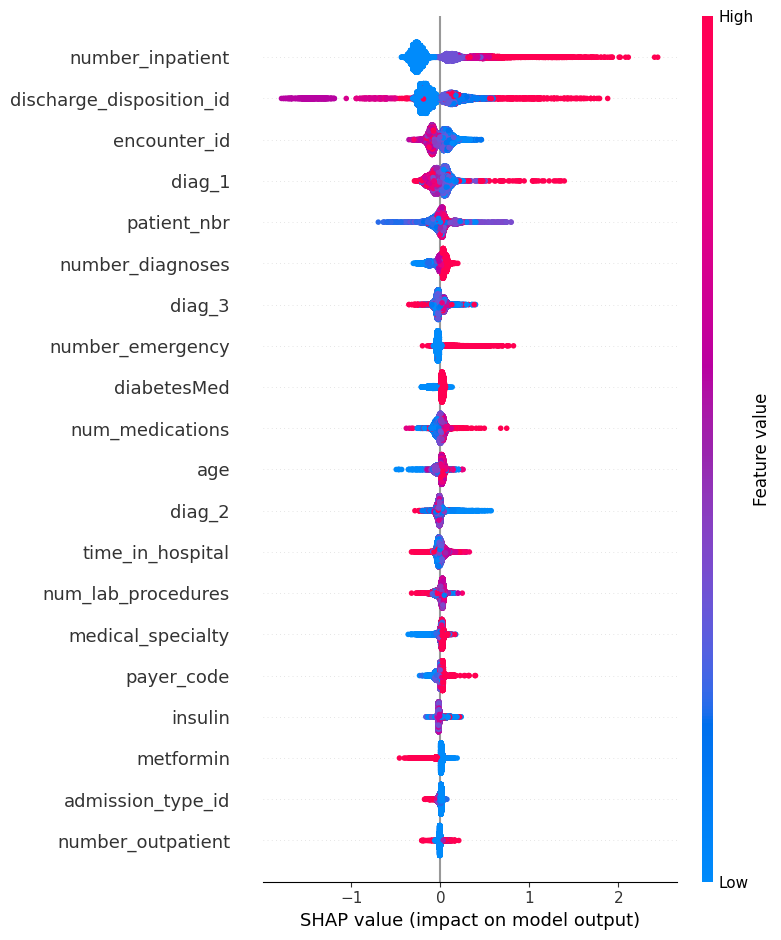

In [2]:
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
tree_classifier = xgb.XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)
tree_classifier.fit(train_x, train_y)
shap.initjs()
explainer_object = shap.TreeExplainer(tree_classifier)
shap_values = explainer_object.shap_values(test_x)
shap.summary_plot(shap_values, test_x)

In [3]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00296/dataset_diabetes.zip
!unzip -o dataset_diabetes.zip

--2026-08-11 11:38:13--  https://archive.ics.uci.edu/ml/machine-learning-databases/00296/dataset_diabetes.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘dataset_diabetes.zip.1’

dataset_diabetes.zi     [   <=>              ]   3.19M  6.65MB/s    in 0.5s    

2026-08-11 11:38:14 (6.65 MB/s) - ‘dataset_diabetes.zip.1’ saved [3347213]

Archive:  dataset_diabetes.zip
  inflating: dataset_diabetes/diabetic_data.csv  
  inflating: dataset_diabetes/IDs_mapping.csv  


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, precision_recall_curve, f1_score
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
raw_patient_data = pd.read_csv("dataset_diabetes/diabetic_data.csv")
raw_patient_data = raw_patient_data.replace('?', np.nan)
drop_features = ['weight', 'payer_code', 'medical_specialty', 'encounter_id', 'patient_nbr']
cleaned_data = raw_patient_data.drop(columns=drop_features).dropna(subset=['race', 'diag_1', 'diag_2', 'diag_3'])
target_map = {'NO': 0, '>30': 0, '<30': 1}
cleaned_data['readmitted'] = cleaned_data['readmitted'].map(target_map)
numerical_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
categorical_features = [col for col in cleaned_data.columns if col not in numerical_features + ['readmitted']]
feature_matrix = cleaned_data.drop(columns=['readmitted'])
target_vector = cleaned_data['readmitted']
train_features, test_features, train_target, test_target = train_test_split(
    feature_matrix, target_vector, test_size=0.2, random_state=42, stratify=target_vector
)
preprocessing_steps = ColumnTransformer(
    transformers=[
        ('numbers', StandardScaler(), numerical_features),
        ('categories', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)
negative_class_count = (train_target == 0).sum()
positive_class_count = (train_target == 1).sum()
imbalance_ratio = negative_class_count / positive_class_count
gradient_booster = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    eval_metric='aucpr'
)
production_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessing_steps),
    ('classifier', gradient_booster)
])
production_pipeline.fit(train_features, train_target)
predicted_probabilities = production_pipeline.predict_proba(test_features)[:, 1]
precision_array, recall_array, threshold_array = precision_recall_curve(test_target, predicted_probabilities)
f1_scores_array = 2 * (precision_array * recall_array) / (precision_array + recall_array + 1e-10)
optimal_threshold_index = np.argmax(f1_scores_array)
best_decision_threshold = threshold_array[optimal_threshold_index]
final_predictions = (predicted_probabilities >= best_decision_threshold).astype(int)
print(classification_report(test_target, final_predictions))

              precision    recall  f1-score   support

           0       0.92      0.79      0.85     17398
           1       0.21      0.44      0.28      2213

    accuracy                           0.75     19611
   macro avg       0.56      0.61      0.56     19611
weighted avg       0.84      0.75      0.78     19611



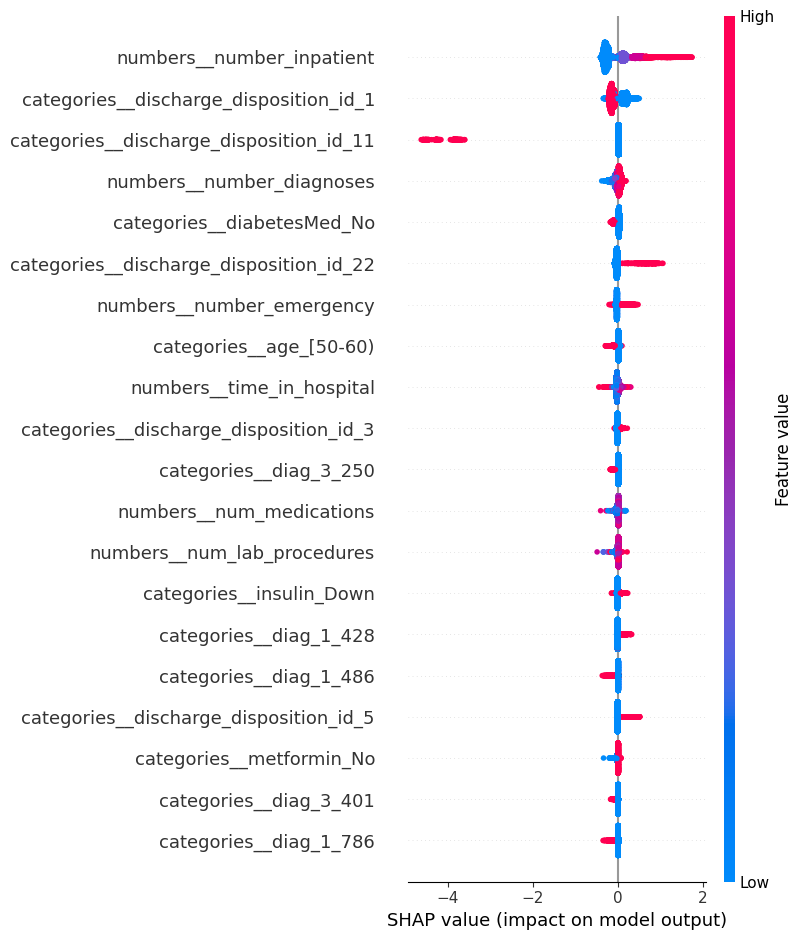

In [5]:
transformed_test_features = production_pipeline.named_steps['preprocessor'].transform(test_features)
feature_names_out = production_pipeline.named_steps['preprocessor'].get_feature_names_out()
shap.initjs()
tree_explainer = shap.TreeExplainer(production_pipeline.named_steps['classifier'])
shap_matrix = tree_explainer.shap_values(transformed_test_features)
shap.summary_plot(shap_matrix, transformed_test_features, feature_names=feature_names_out)